Dataset loaded. Total training tiles: 787


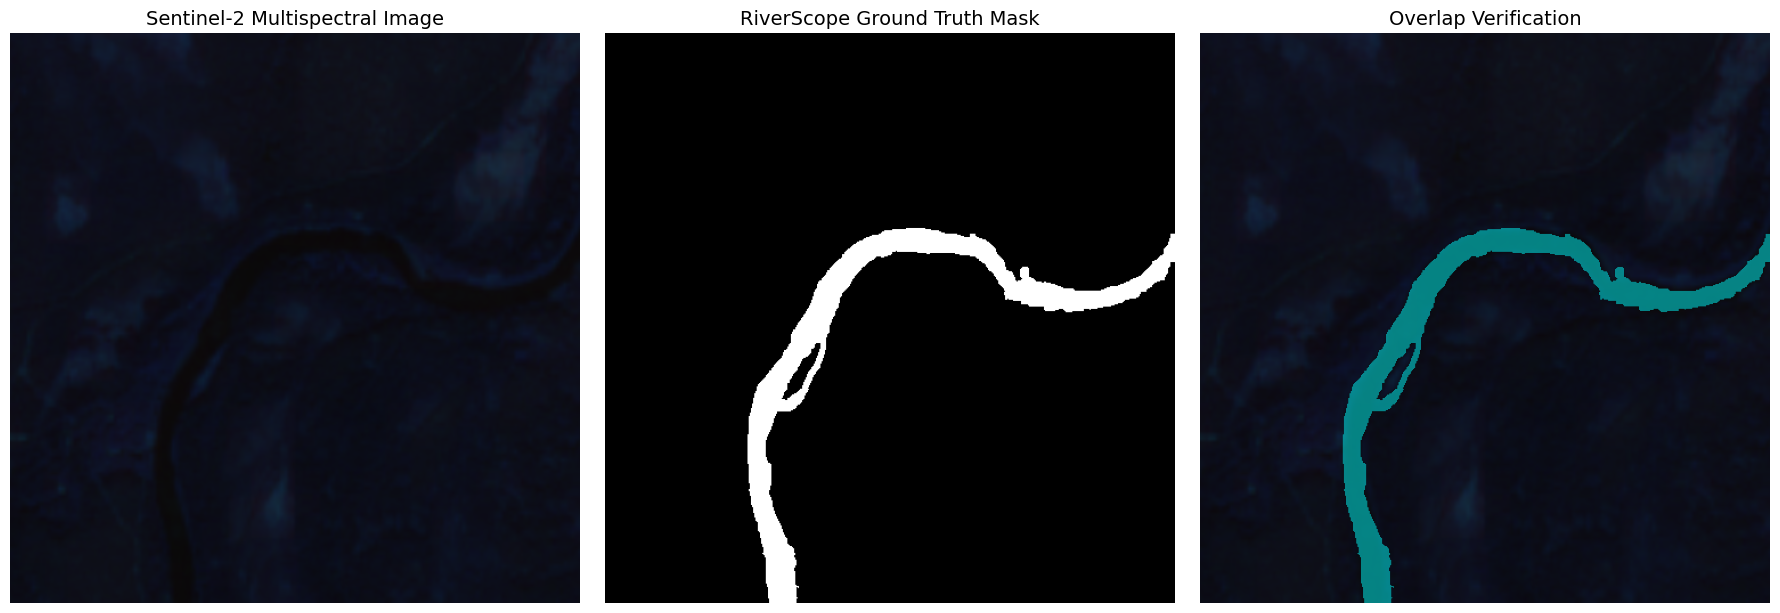

In [1]:
import os
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP PATHS
# ==========================================
# Pointing to the structure shown in your screenshot
DATA_ROOT = "../data/raw/RiverScope_dataset"
CSV_PATH = os.path.join(DATA_ROOT, "train.csv")

# Load the CSV
df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded. Total training tiles: {len(df)}")

# ==========================================
# 2. SELECT A SAMPLE
# ==========================================
# Let's grab the very first image. Change this index to look at different tiles!
sample_idx = 0 
sample = df.iloc[sample_idx]

s2_path = os.path.join(DATA_ROOT, sample['s2_path_reprojected'])
label_path = os.path.join(DATA_ROOT, sample['label_path'])

# ==========================================
# 3. LOAD SENTINEL-2 IMAGERY
# ==========================================
with rasterio.open(s2_path) as src:
    # Read the first 3 bands (RGB)
    img = src.read([1, 2, 3])
    # Convert from [Channels, H, W] to [H, W, Channels] for Matplotlib
    img = np.transpose(img, (1, 2, 0))
    
    # Sentinel-2 stores reflectance (0 to ~10000). We divide by 10000.
    # We multiply by 2.5 to artificially boost the brightness so it's easier to see!
    img = np.clip(img / 10000.0 * 2.5, 0, 1)

# ==========================================
# 4. LOAD GROUND TRUTH MASK
# ==========================================
with rasterio.open(label_path) as src:
    mask = src.read(1)
    
    # In RiverScope: 1 = river. We want a binary mask of just the river.
    river_mask = (mask == 1).astype(np.float32)

# ==========================================
# 5. VISUALIZE THE OVERLAP
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: The Raw Satellite Image
axes[0].imshow(img)
axes[0].set_title("Sentinel-2 Multispectral Image", fontsize=14)
axes[0].axis("off")

# Plot 2: The Binary Label
axes[1].imshow(river_mask, cmap="gray")
axes[1].set_title("RiverScope Ground Truth Mask", fontsize=14)
axes[1].axis("off")

# Plot 3: The Overlay (The Sanity Check)
axes[2].imshow(img)
# We use np.ma.masked_where to make the background (0) completely transparent 
# so only the river pixels overlay onto the image.
overlay = np.ma.masked_where(river_mask == 0, river_mask)
axes[2].imshow(overlay, cmap="cool", alpha=0.5) # alpha=0.5 makes it semi-transparent
axes[2].set_title("Overlap Verification", fontsize=14)
axes[2].axis("off")

plt.tight_layout()
plt.show()